In [28]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import plotly.offline as offline

import altair as alt

In [4]:
df = pd.read_csv('fec/totals-2020-01-20T18_57_22.csv')
df['cash'] = df['cash_on_hand_end_period'].apply(lambda x: '${:,d}'.format(int(x)))

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 44 columns):
name                        16 non-null object
office                      16 non-null object
office_full                 16 non-null object
party                       16 non-null object
party_full                  16 non-null object
state                       16 non-null object
district                    16 non-null int64
district_number             16 non-null int64
election_districts          16 non-null object
election_years              16 non-null object
cycles                      16 non-null object
candidate_status            16 non-null object
incumbent_challenge         15 non-null object
incumbent_challenge_full    15 non-null object
load_date                   16 non-null object
first_file_date             16 non-null object
last_file_date              16 non-null object
last_f2_date                16 non-null object
candidate_id                16 non-null object
two_ye

In [6]:
df = df.sort_values('cash_on_hand_end_period')

In [7]:
trace_microbar = go.Bar(x=df.name, y=df.cash_on_hand_end_period)

data = trace_microbar

In [8]:
layout = go.Layout(title = 'District 11 Candidates: Cash on Hand')

In [9]:
figure = go.Figure(data = data, layout = layout)

In [10]:
# offline.plot(
#     figure, 
#     config={
#         'displayModeBar': False
#     }
# )

## Installing plotly for jupyter labs

There's more setup for plotly to work with jupyter labs, so make sure to follow the instructions below to make sure you can view widgets directly in your notebook.

[Instructions](https://plot.ly/python/getting-started/#jupyterlab-support-python-35)

In [11]:
f = go.FigureWidget(figure)

In [12]:
f

FigureWidget({
    'data': [{'type': 'bar',
              'uid': '1c023af8-6b29-411d-8681-57930e1efa4c',
     …

## JS

Remember: everything you do has to be viewed on cvhp, unless you're going to start an independent outlet with python support on the backend.

Consider learning and using plotly.js to make sure you're creating code that can be run within a wordpress page. 

In [13]:
import pygal
import cairosvg

from pygal.style import DarkSolarizedStyle
from pygal.style import RedBlueStyle

In [14]:
df_contribs_1 = pd.read_csv('fec/contribs_pfluger-berryhill.csv')
df_contribs_2 = pd.read_csv('fec/contribs_cady-schumann.csv')

In [15]:
df_conaway = pd.read_csv('fec/conaway.csv')

In [16]:
frames = [df_contribs_1, df_contribs_2, df_conaway]

In [17]:
df_contribs = pd.concat(frames)

In [18]:
df_contribs.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 919 entries, 0 to 448
Data columns (total 79 columns):
committee_id                             919 non-null object
committee_name                           919 non-null object
report_year                              919 non-null int64
report_type                              919 non-null object
image_number                             919 non-null int64
line_number                              919 non-null object
transaction_id                           917 non-null object
file_number                              919 non-null int64
committee_name.1                         0 non-null float64
entity_type                              919 non-null object
entity_type_desc                         919 non-null object
unused_contbr_id                         252 non-null object
contributor_prefix                       298 non-null object
contributor_name                         919 non-null object
recipient_committee_type                 919 

In [19]:
contribs_grouped = df_contribs.groupby('committee_name').contribution_receipt_amount.sum()

In [20]:
# contribs_grouped.to_csv('fec/contribs_sum.csv', headers=True)

In [21]:
contribs = pd.read_csv('fec/contribs_sum.csv')

In [22]:
merged = pd.merge(df, contribs, on='name')

In [23]:
merged.head()

,name,office,office_full,party,party_full,state,district,district_number,election_districts,election_years,...,debts_owed_by_committee,coverage_start_date,coverage_end_date,federal_funds_flag,has_raised_funds,party.1,office.1,candidate_inactive.1,cash,contributions
0,Ross Alan Schumann,H,House,REP,REPUBLICAN PARTY,TX,11,11,{11},{2020},...,0.0,NaN,NaN,f,f,REP,H,f,$0,0.0
1,Brandon Batch,H,House,REP,REPUBLICAN PARTY,TX,11,11,{11},{2020},...,0.0,NaN,NaN,f,f,REP,H,f,$0,0.0
2,Wesley Virdell,H,House,REP,REPUBLICAN PARTY,TX,11,11,{11},{2020},...,0.0,NaN,NaN,f,f,REP,H,f,$0,0.0
3,Richard Bartlett,H,House,REP,REPUBLICAN PARTY,TX,11,11,{11},{2020},...,0.0,2019-07-01 00:00:00,2019-12-31 00:00:00,f,t,REP,H,f,$0,22350.0
4,Wacey Alpha Cody,H,House,LIB,LIBERTARIAN PARTY,TX,11,11,{11},{2020},...,0.0,NaN,NaN,f,f,LIB,H,f,$0,0.0


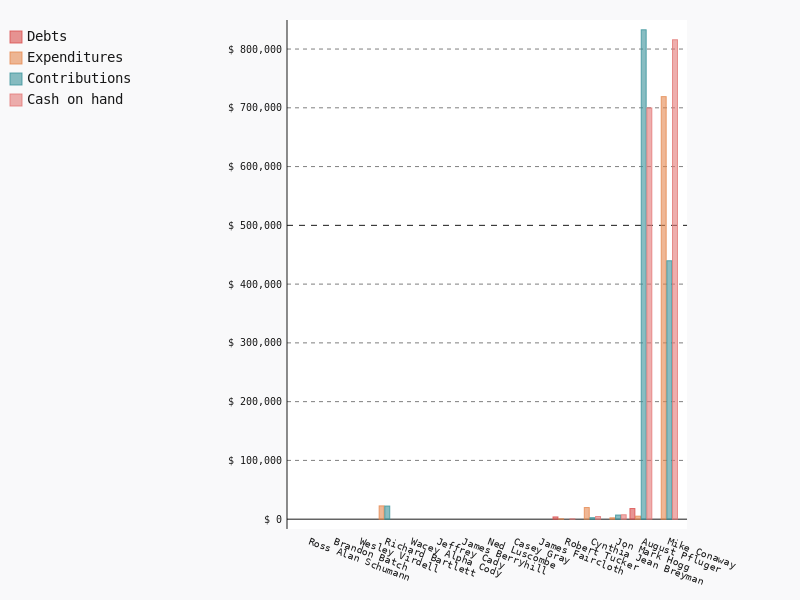

In [24]:
bar_chart = pygal.Bar(x_label_rotation=20, style=RedBlueStyle)

bar_chart.x_labels = (merged['name'])
bar_chart.value_formatter = lambda y: '${:20,.0f}'.format(y)
bar_chart.add('Debts', merged['debts_owed_by_committee'])
bar_chart.add('Expenditures', merged['disbursements'])
bar_chart.add('Contributions', merged['contributions'])
bar_chart.add('Cash on hand', merged['cash_on_hand_end_period'])

In [25]:
bar_chart.render_in_browser()

file:///tmp/tmp946d8tye.html


In [102]:
totals_2019 = pd.read_csv('fec/totals_2019.csv')
totals_2019 = totals_2019.sort_values('cash_on_hand_end_period').reset_index(drop=True)
# totals_2019 = totals_2019.drop([11])
totals_2019

,name,receipts,disbursements,cash_on_hand_end_period,debts_owed_by_committee
0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,Brandon Batch,0.00,0.00,0.00,0.00
2,Wesley Virdell,0.00,0.00,0.00,0.00
3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,James Berryhill,0.00,0.00,0.00,0.00
7,Ned Luscombe,0.00,0.00,0.00,0.00
8,Casey Gray,0.00,0.00,0.00,0.00
9,James Faircloth,0.00,0.00,0.00,0.00


In [104]:
totals_2019 = totals_2019.reset_index(drop=False)
totals_2019

,level_0,index,name,receipts,disbursements,cash_on_hand_end_period,debts_owed_by_committee
0,0,0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,1,1,Brandon Batch,0.00,0.00,0.00,0.00
2,2,2,Wesley Virdell,0.00,0.00,0.00,0.00
3,3,3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,4,4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,5,5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,6,6,James Berryhill,0.00,0.00,0.00,0.00
7,7,7,Ned Luscombe,0.00,0.00,0.00,0.00
8,8,8,Casey Gray,0.00,0.00,0.00,0.00
9,9,9,James Faircloth,0.00,0.00,0.00,0.00


In [150]:
totals_2019.level_0 = totals_2019.index * 20
totals_2019

,level_0,index,name,receipts,disbursements,cash_on_hand_end_period,debts_owed_by_committee
0,0,0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,20,1,Brandon Batch,0.00,0.00,0.00,0.00
2,40,2,Wesley Virdell,0.00,0.00,0.00,0.00
3,60,3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,80,4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,100,5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,120,6,James Berryhill,0.00,0.00,0.00,0.00
7,140,7,Ned Luscombe,0.00,0.00,0.00,0.00
8,160,8,Casey Gray,0.00,0.00,0.00,0.00
9,180,9,James Faircloth,0.00,0.00,0.00,0.00


In [51]:
all_totals = pd.merge(totals_2019, contribs, on='name')
# all_totals.to_csv('fec/all_totals_2019.csv', header=True)
# all_totals.to_json('fec/all_totals_2019.json', orient='index')

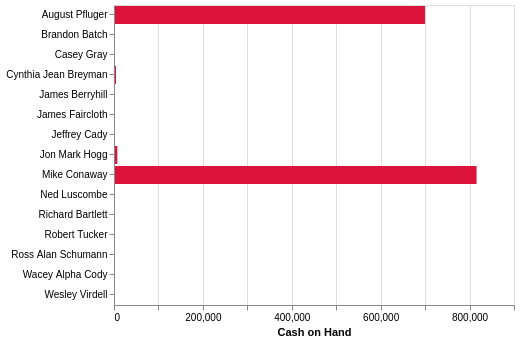

In [52]:
chart = alt.Chart(all_totals).mark_bar(color='crimson').encode(
    alt.X('cash_on_hand_end_period', title='Cash on Hand'),
    alt.Y('name', title=None)
)

chart

In [43]:
chart.save('vegachart.html')

In [59]:
json = pd.read_json('fec/all_totals_2019.json')

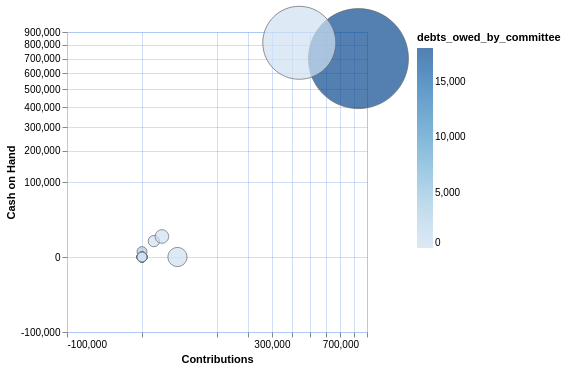

In [352]:
selection = alt.selection_single(on='mouseover', fields=['name','cash_on_hand_end_period', 'contributions'])

# color = alt.condition(selection,
#                      alt.Color('name:N', legend=None),
#                       alt.value('lightgray')
#                      )

def mult_index(number):
    return number * 10

bubble = alt.Chart(all_totals, width=300, height=300,).mark_circle(strokeWidth=1, strokeOpacity=1, stroke='#666666').encode(
    alt.X('contributions:Q', scale=alt.Scale(zero=False, type='sqrt'), title='Contributions'),
    alt.Y('cash_on_hand_end_period:Q', scale=alt.Scale(zero=False, type='sqrt'), sort='ascending', title='Cash on Hand'),
    alt.Size('contributions:Q', scale=alt.Scale(range=[100, 10000]), legend=None),
    tooltip=[
        alt.Tooltip(title='Name', field='name', type='ordinal'),
        alt.Tooltip(title='Contributions', field='contributions', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Cash on Hand', field='cash_on_hand_end_period', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Disbursements', field='disbursements', format="$,.0f", type='ordinal'),
        alt.Tooltip(title='Debts', field='debts_owed_by_committee', format="$,.0f", type='ordinal')
    ],
    color = alt.Color('debts_owed_by_committee:Q'),
#     strokeWidth='1:O'
    
).add_selection(
    selection
).configure_axis(
    gridOpacity=0.3,
    gridColor='cornflowerblue',
    domain=False
).configure_view(
    strokeWidth=1,
    stroke='cornflowerblue',
    strokeOpacity=0.3
).configure_scale(
    minSize=100,
    continuousPadding=4,
    maxOpacity=0.9,
    minOpacity=0.4,
    pointPadding=0.3,
).configure_legend(
    offset=50
)

bubble

In [353]:
bubble.save('vegabubble.html')